# Healthcare Spending & Hospital Readmissions Analysis

**Author:** Abood Shurbjy — Chemical & Biomolecular Engineering, University of Pennsylvania

---

## Research Question

> **Does higher Medicare spending per hospital episode actually lead to fewer patient readmissions?**

Hospital readmissions are a major quality and cost concern in the U.S. healthcare system. The Centers for Medicare & Medicaid Services (CMS) penalizes hospitals with higher-than-expected readmission rates through the **Hospital Readmissions Reduction Program (HRRP)**. At the same time, CMS tracks how much Medicare spends per patient episode at each hospital.

This analysis merges three public CMS datasets — covering hospital characteristics, readmission performance, and Medicare spending — to explore whether spending more per patient actually translates to better outcomes (i.e., fewer readmissions). We examine ~3,000 U.S. hospitals across 6 medical conditions.

---

## Setup & Imports

We begin by importing the libraries we'll use throughout this analysis and configuring our visualization style for a clean, professional look.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import requests
import os
import warnings

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

# Set visualization defaults
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 11

# Use seaborn's colorblind-friendly palette
PALETTE = sns.color_palette("colorblind")
sns.set_palette("colorblind")

# Paths
DATA_DIR = os.path.join('..', 'data')
FIG_DIR = os.path.join('..', 'figures')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("Setup complete.")

Setup complete.


---

## Step 1: Data Acquisition

We download three datasets directly from the CMS Provider Data Catalog API. These are publicly available and free to use:

| Dataset | Description |
|---------|------------|
| **Hospital General Information** | Basic hospital characteristics — location, type, ownership, and overall quality rating |
| **Hospital Readmissions Reduction Program** | Excess readmission ratios for 6 conditions at each hospital |
| **Medicare Spending Per Beneficiary** | How much Medicare spends per patient episode compared to the national median |

The data files are stored locally in `data/` so we only download them once.

In [2]:
# Define datasets to download
datasets = {
    'hospital_info': {
        'catalog_id': 'xubh-q36u',
        'filename': 'hospital_general_info.csv',
        'description': 'Hospital General Information'
    },
    'readmissions': {
        'catalog_id': '9n3s-kdb3',
        'filename': 'hospital_readmissions.csv',
        'description': 'Hospital Readmissions Reduction Program'
    },
    'spending': {
        'catalog_id': 'rrqw-56er',
        'filename': 'medicare_spending.csv',
        'description': 'Medicare Spending Per Beneficiary - Hospital'
    }
}

def download_cms_data(catalog_id, filepath, description):
    """Download a CMS dataset, trying multiple URL patterns."""
    if os.path.exists(filepath):
        print(f"  Already downloaded: {description}")
        return True
    
    # URL patterns to try
    urls = [
        f"https://data.cms.gov/provider-data/api/1/datastore/query/{catalog_id}/0/download?format=csv",
        f"https://data.cms.gov/provider-data/sites/default/files/resources/{catalog_id}_0.csv",
    ]
    
    for i, url in enumerate(urls):
        try:
            print(f"  Trying URL pattern {i+1} for {description}...")
            response = requests.get(url, timeout=60)
            if response.status_code == 200 and len(response.content) > 1000:
                with open(filepath, 'wb') as f:
                    f.write(response.content)
                size_mb = len(response.content) / (1024 * 1024)
                print(f"  Downloaded {description} ({size_mb:.1f} MB)")
                return True
        except requests.RequestException as e:
            print(f"  URL pattern {i+1} failed: {e}")
    
    # Try metadata endpoint to find the actual download URL
    try:
        print(f"  Trying metadata endpoint for {description}...")
        meta_url = f"https://data.cms.gov/provider-data/api/1/metastore/schemas/dataset/items/{catalog_id}?show-reference-ids=true"
        meta_resp = requests.get(meta_url, timeout=30)
        if meta_resp.status_code == 200:
            meta = meta_resp.json()
            for dist in meta.get('distribution', []):
                download_url = dist.get('data', {}).get('downloadURL') or dist.get('downloadURL', '')
                if download_url and 'csv' in download_url.lower():
                    response = requests.get(download_url, timeout=60)
                    if response.status_code == 200 and len(response.content) > 1000:
                        with open(filepath, 'wb') as f:
                            f.write(response.content)
                        size_mb = len(response.content) / (1024 * 1024)
                        print(f"  Downloaded {description} via metadata ({size_mb:.1f} MB)")
                        return True
    except Exception as e:
        print(f"  Metadata approach failed: {e}")
    
    print(f"  WARNING: Could not download {description}. Please download manually.")
    return False

# Download all datasets
print("Downloading CMS datasets...\n")
for key, info in datasets.items():
    filepath = os.path.join(DATA_DIR, info['filename'])
    download_cms_data(info['catalog_id'], filepath, info['description'])
    print()

print("Data acquisition complete.")


  Trying URL pattern 1 for Hospital General Information...


  Downloaded Hospital General Information (1.5 MB)

  Trying URL pattern 1 for Hospital Readmissions Reduction Program...


  Downloaded Hospital Readmissions Reduction Program (2.0 MB)

  Trying URL pattern 1 for Medicare Spending Per Beneficiary - Hospital...


  Downloaded Medicare Spending Per Beneficiary - Hospital (1.0 MB)

Data acquisition complete.


---

## Step 2: Data Loading & Inspection

Let's load each dataset and examine its structure — number of rows/columns, data types, and a preview of the first few records. This helps us understand what we're working with before cleaning.

In [3]:
# Load datasets
df_hospital = pd.read_csv(os.path.join(DATA_DIR, 'hospital_general_info.csv'), dtype=str)
df_readmit = pd.read_csv(os.path.join(DATA_DIR, 'hospital_readmissions.csv'), dtype=str)
df_spending = pd.read_csv(os.path.join(DATA_DIR, 'medicare_spending.csv'), dtype=str)

print("Dataset shapes:")
print(f"  Hospital Info:    {df_hospital.shape[0]:,} rows x {df_hospital.shape[1]} columns")
print(f"  Readmissions:     {df_readmit.shape[0]:,} rows x {df_readmit.shape[1]} columns")
print(f"  Medicare Spending: {df_spending.shape[0]:,} rows x {df_spending.shape[1]} columns")

Dataset shapes:
  Hospital Info:    5,426 rows x 38 columns
  Readmissions:     18,330 rows x 12 columns
  Medicare Spending: 4,625 rows x 14 columns


### Hospital General Information

This dataset contains one row per hospital with basic information like location, type, ownership, and the CMS overall quality star rating (1-5).

In [4]:
print("Columns:", list(df_hospital.columns))
print()
df_hospital.head(3)

Columns: ['Facility ID', 'Facility Name', 'Address', 'City/Town', 'State', 'ZIP Code', 'County/Parish', 'Telephone Number', 'Hospital Type', 'Hospital Ownership', 'Emergency Services', 'Meets criteria for birthing friendly designation', 'Hospital overall rating', 'Hospital overall rating footnote', 'MORT Group Measure Count', 'Count of Facility MORT Measures', 'Count of MORT Measures Better', 'Count of MORT Measures No Different', 'Count of MORT Measures Worse', 'MORT Group Footnote', 'Safety Group Measure Count', 'Count of Facility Safety Measures', 'Count of Safety Measures Better', 'Count of Safety Measures No Different', 'Count of Safety Measures Worse', 'Safety Group Footnote', 'READM Group Measure Count', 'Count of Facility READM Measures', 'Count of READM Measures Better', 'Count of READM Measures No Different', 'Count of READM Measures Worse', 'READM Group Footnote', 'Pt Exp Group Measure Count', 'Count of Facility Pt Exp Measures', 'Pt Exp Group Footnote', 'TE Group Measure Co

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,...,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,READM Group Footnote,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,Pt Exp Group Footnote,TE Group Measure Count,Count of Facility TE Measures,TE Group Footnote
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,...,0,11,0,NaN,8,8,NaN,12,11,NaN
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,...,0,8,1,NaN,8,8,NaN,12,12,NaN
2,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Acute Care Hospitals,Proprietary,...,0,8,1,NaN,8,8,NaN,12,10,NaN


### Hospital Readmissions Reduction Program

This dataset has multiple rows per hospital — one for each medical condition tracked by the HRRP. The key metric is the **Excess Readmission Ratio (ERR)**: a value of 1.0 means readmissions match the expected rate, above 1.0 means more readmissions than expected.

In [5]:
print("Columns:", list(df_readmit.columns))
print()
df_readmit.head(3)

Columns: ['Facility Name', 'Facility ID', 'State', 'Measure Name', 'Number of Discharges', 'Footnote', 'Excess Readmission Ratio', 'Predicted Readmission Rate', 'Expected Readmission Rate', 'Number of Readmissions', 'Start Date', 'End Date']



,Facility Name,Facility ID,State,Measure Name,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date
0,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-HIP-KNEE-HRRP,NaN,NaN,0.9875,4.5734,4.6311,Too Few to Report,07/01/2021,06/30/2024
1,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-CABG-HRRP,137,NaN,0.9531,10.3960,10.9078,13,07/01/2021,06/30/2024
2,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-AMI-HRRP,273,NaN,0.9370,13.2998,14.1948,33,07/01/2021,06/30/2024


### Medicare Spending Per Beneficiary

This dataset compares each hospital's Medicare spending per patient episode to the national median. A value of 1.0 means average spending; values above 1.0 indicate higher-than-average spending.

In [6]:
print("Columns:", list(df_spending.columns))
print()
df_spending.head(3)

Columns: ['Facility ID', 'Facility Name', 'Address', 'City/Town', 'State', 'ZIP Code', 'County/Parish', 'Telephone Number', 'Measure ID', 'Measure Name', 'Score', 'Footnote', 'Start Date', 'End Date']



,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Measure ID,Measure Name,Score,Footnote,Start Date,End Date
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MSPB-1,Medicare hospital spending per patient (Medica...,0.99,NaN,01/01/2024,12/31/2024
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,MSPB-1,Medicare hospital spending per patient (Medica...,1.00,NaN,01/01/2024,12/31/2024
2,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,MSPB-1,Medicare hospital spending per patient (Medica...,1.01,NaN,01/01/2024,12/31/2024


---

## Step 3: Data Cleaning

Each dataset needs targeted cleaning before we can merge them. The main challenges are:
- Non-numeric values like "Not Available" and "Too Few to Report" in numeric columns
- Multiple rows per hospital in the readmissions data (one per condition)
- Identifying the right spending measure from multiple claim types

### 3a. Clean Hospital General Information

We keep only the columns relevant to our analysis and convert the star rating to a proper numeric type.

In [7]:
# Standardize column names — CMS datasets sometimes vary in naming conventions
# We'll find the actual column names and map them

def find_column(df, possible_names):
    """Find a column by trying multiple possible names (case-insensitive)."""
    cols_lower = {c.lower().strip(): c for c in df.columns}
    for name in possible_names:
        if name.lower() in cols_lower:
            return cols_lower[name.lower()]
    return None

# Identify key columns in hospital info
hosp_col_map = {
    'facility_id': find_column(df_hospital, ['Facility ID', 'facility_id', 'Provider ID', 'provider_id',
                                              'Facility Id', 'CMS Certification Number (CCN)', 'ccn']),
    'facility_name': find_column(df_hospital, ['Facility Name', 'facility_name', 'Hospital Name', 'hospital_name']),
    'city': find_column(df_hospital, ['City/Town', 'city/town', 'City', 'city']),
    'state': find_column(df_hospital, ['State', 'state']),
    'zip_code': find_column(df_hospital, ['ZIP Code', 'zip_code', 'Zip Code', 'ZIP code']),
    'county': find_column(df_hospital, ['County/Parish', 'county/parish', 'County Name', 'county_name']),
    'hospital_type': find_column(df_hospital, ['Hospital Type', 'hospital_type']),
    'ownership': find_column(df_hospital, ['Hospital Ownership', 'hospital_ownership', 'Hospital ownership']),
    'rating': find_column(df_hospital, ['Hospital overall rating', 'hospital_overall_rating',
                                         'Overall Rating', 'overall_rating',
                                         'Hospital Overall Rating'])
}

print("Detected hospital info columns:")
for key, val in hosp_col_map.items():
    print(f"  {key}: {val}")

# Filter to columns we found
found_cols = {k: v for k, v in hosp_col_map.items() if v is not None}
df_hospital_clean = df_hospital[[v for v in found_cols.values()]].copy()
df_hospital_clean.columns = [k for k in found_cols.keys()]

# Convert star rating to numeric
if 'rating' in df_hospital_clean.columns:
    df_hospital_clean['rating'] = pd.to_numeric(df_hospital_clean['rating'], errors='coerce')

print(f"\nCleaned hospital info: {df_hospital_clean.shape[0]:,} hospitals")
print(f"Star rating coverage: {df_hospital_clean['rating'].notna().sum():,} hospitals with ratings")
df_hospital_clean.head(3)

Detected hospital info columns:
  facility_id: Facility ID
  facility_name: Facility Name
  city: City/Town
  state: State
  zip_code: ZIP Code
  county: County/Parish
  hospital_type: Hospital Type
  ownership: Hospital Ownership
  rating: Hospital overall rating

Cleaned hospital info: 5,426 hospitals
Star rating coverage: 2,866 hospitals with ratings


,facility_id,facility_name,city,state,zip_code,county,hospital_type,ownership,rating
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,36301,HOUSTON,Acute Care Hospitals,Government - Hospital District or Authority,4.0
1,010005,MARSHALL MEDICAL CENTERS,BOAZ,AL,35957,MARSHALL,Acute Care Hospitals,Government - Hospital District or Authority,3.0
2,010006,NORTH ALABAMA MEDICAL CENTER,FLORENCE,AL,35630,LAUDERDALE,Acute Care Hospitals,Proprietary,2.0


### 3b. Clean Readmissions Data

The readmissions dataset has multiple rows per hospital — one per medical condition. We need to:
1. Identify the Excess Readmission Ratio column and the condition/measure column
2. Filter to the 6 HRRP conditions (AMI, HF, PN, COPD, HIP/KNEE, CABG)
3. Convert ratios to numeric
4. Pivot the data so each hospital gets one row with condition-specific columns
5. Compute an average ERR across all applicable conditions

In [8]:
# Identify key columns in readmissions data
readmit_facility_col = find_column(df_readmit, ['Facility ID', 'facility_id', 'Provider ID', 'provider_id',
                                                  'Facility Id', 'Hospital CCN', 'ccn'])
readmit_measure_col = find_column(df_readmit, ['Measure Name', 'measure_name', 'Condition', 'condition',
                                                 'Measure', 'measure'])
readmit_err_col = find_column(df_readmit, ['Excess Readmission Ratio', 'excess_readmission_ratio',
                                             'Excess readmission ratio', 'ERR'])
readmit_discharges_col = find_column(df_readmit, ['Number of Discharges', 'number_of_discharges',
                                                    'Number of discharges', 'Predicted Readmission Rate',
                                                    'Discharges'])

print("Detected readmissions columns:")
print(f"  Facility ID: {readmit_facility_col}")
print(f"  Measure/Condition: {readmit_measure_col}")
print(f"  Excess Readmission Ratio: {readmit_err_col}")
print(f"  Discharges: {readmit_discharges_col}")

# See unique measures/conditions
if readmit_measure_col:
    print(f"\nUnique measures ({df_readmit[readmit_measure_col].nunique()}):")
    for m in sorted(df_readmit[readmit_measure_col].unique()):
        print(f"  - {m}")

Detected readmissions columns:
  Facility ID: Facility ID
  Measure/Condition: Measure Name
  Excess Readmission Ratio: Excess Readmission Ratio
  Discharges: Number of Discharges

Unique measures (6):
  - READM-30-AMI-HRRP
  - READM-30-CABG-HRRP
  - READM-30-COPD-HRRP
  - READM-30-HF-HRRP
  - READM-30-HIP-KNEE-HRRP
  - READM-30-PN-HRRP


In [9]:
# Define the 6 HRRP conditions and map them to short labels
# We'll match on substrings since exact names vary across dataset versions
CONDITION_MAP = {
    'AMI': ['ami', 'heart attack', 'acute myocardial'],
    'HF': ['hf', 'heart failure'],
    'PN': ['pn', 'pneumonia'],
    'COPD': ['copd', 'chronic obstructive', 'pulmonary disease'],
    'HIP/KNEE': ['hip', 'knee', 'hip/knee', 'total hip', 'arthroplasty'],
    'CABG': ['cabg', 'coronary artery bypass', 'bypass graft']
}

def classify_condition(measure_name):
    """Map a measure name to one of the 6 HRRP condition labels."""
    if pd.isna(measure_name):
        return None
    name_lower = str(measure_name).lower()
    for label, keywords in CONDITION_MAP.items():
        for kw in keywords:
            if kw in name_lower:
                return label
    return None

# Apply condition classification
df_readmit['condition'] = df_readmit[readmit_measure_col].apply(classify_condition)

# Filter to recognized HRRP conditions only
df_readmit_filtered = df_readmit[df_readmit['condition'].notna()].copy()
print(f"Rows matching HRRP conditions: {len(df_readmit_filtered):,} out of {len(df_readmit):,}")
print(f"\nCondition distribution:")
print(df_readmit_filtered['condition'].value_counts())

Rows matching HRRP conditions: 18,330 out of 18,330

Condition distribution:
condition
HIP/KNEE    3055
CABG        3055
AMI         3055
COPD        3055
PN          3055
HF          3055
Name: count, dtype: int64


In [10]:
# Convert Excess Readmission Ratio to numeric
df_readmit_filtered['err'] = pd.to_numeric(df_readmit_filtered[readmit_err_col], errors='coerce')

print(f"ERR values: {df_readmit_filtered['err'].notna().sum():,} valid out of {len(df_readmit_filtered):,}")
print(f"\nERR summary statistics:")
print(df_readmit_filtered['err'].describe().round(4))

# Pivot: one row per hospital, one column per condition's ERR
df_readmit_pivot = df_readmit_filtered.pivot_table(
    index=readmit_facility_col,
    columns='condition',
    values='err',
    aggfunc='mean'
)

# Rename columns to be descriptive
df_readmit_pivot.columns = [f'ERR_{col}' for col in df_readmit_pivot.columns]

# Compute average ERR across all conditions for each hospital
err_cols = [c for c in df_readmit_pivot.columns if c.startswith('ERR_')]
df_readmit_pivot['avg_err'] = df_readmit_pivot[err_cols].mean(axis=1)

# Reset index so facility ID is a regular column
df_readmit_pivot = df_readmit_pivot.reset_index()
df_readmit_pivot = df_readmit_pivot.rename(columns={readmit_facility_col: 'facility_id'})

print(f"\nPivoted readmissions: {df_readmit_pivot.shape[0]:,} hospitals")
df_readmit_pivot.head(3)

ERR values: 11,720 valid out of 18,330

ERR summary statistics:
count    11720.0000
mean         1.0018
std          0.0821
min          0.4698
25%          0.9582
50%          0.9973
75%          1.0423
max          1.6297
Name: err, dtype: float64

Pivoted readmissions: 2,833 hospitals


,facility_id,ERR_AMI,ERR_CABG,ERR_COPD,ERR_HF,ERR_HIP/KNEE,ERR_PN,avg_err
0,010001,0.9370,0.9531,0.9823,1.0233,0.9875,0.9871,0.978383
1,010005,NaN,NaN,0.9308,1.0087,0.8602,0.8727,0.918100
2,010006,0.9195,1.0027,1.0520,0.9925,1.0527,0.9819,1.000217


### 3c. Clean Medicare Spending Data

The Medicare Spending Per Beneficiary (MSPB) dataset may have multiple rows per hospital (broken down by claim type or spending period). We need to identify the **overall episode spending ratio** and keep one value per hospital.

The MSPB score compares a hospital's spending to the national median:
- **1.0** = spending matches the national median
- **> 1.0** = the hospital spends more than average
- **< 1.0** = the hospital spends less than average

In [11]:
# Identify key columns
spend_facility_col = find_column(df_spending, ['Facility ID', 'facility_id', 'Provider ID', 'provider_id',
                                                'Facility Id', 'Hospital CCN', 'ccn'])
spend_measure_col = find_column(df_spending, ['Measure Name', 'measure_name', 'Measure', 'measure',
                                               'MSPB Measure', 'Payment Measure Name',
                                               'Payment measure name'])
spend_score_col = find_column(df_spending, ['Score', 'score', 'MSPB Score', 'Avg Spending Per Episode (Hospital)',
                                             'avg_spending_per_episode_hospital',
                                             'Avg spending per episode hospital',
                                             'Average Spending Per Episode',
                                             'Spending per Hospital Patient with Medicare'])

print("Detected spending columns:")
print(f"  Facility ID: {spend_facility_col}")
print(f"  Measure: {spend_measure_col}")
print(f"  Score: {spend_score_col}")

# Check if there's a measure column to filter on
if spend_measure_col:
    print(f"\nUnique measures:")
    for m in sorted(df_spending[spend_measure_col].unique()):
        print(f"  - {m}")

Detected spending columns:
  Facility ID: Facility ID
  Measure: Measure Name
  Score: Score

Unique measures:
  - Medicare hospital spending per patient (Medicare Spending per Beneficiary)


In [12]:
# Filter to overall/total spending measure if applicable
df_spend_filtered = df_spending.copy()

if spend_measure_col:
    # Look for the overall/total episode measure
    measures = df_spending[spend_measure_col].unique()
    overall_keywords = ['overall', 'total', 'mspb', 'spending per beneficiary', 'episode']
    
    # If there's only one measure or a clear overall measure, use it
    if len(measures) == 1:
        print(f"Single measure found: {measures[0]}")
    else:
        # Try to find the overall measure
        for m in measures:
            if any(kw in str(m).lower() for kw in overall_keywords):
                df_spend_filtered = df_spending[df_spending[spend_measure_col] == m].copy()
                print(f"Filtered to measure: {m}")
                break

# Convert spending score to numeric
df_spend_filtered['spending_ratio'] = pd.to_numeric(df_spend_filtered[spend_score_col], errors='coerce')

# If values are dollar amounts (> 10), normalize to a ratio around 1.0
median_spending = df_spend_filtered['spending_ratio'].median()
if median_spending > 10:  # These are dollar amounts, not ratios
    print(f"\nSpending appears to be in dollars (median: ${median_spending:,.0f})")
    print("Normalizing to ratio (hospital / national median)...")
    national_median = df_spend_filtered['spending_ratio'].median()
    df_spend_filtered['spending_ratio'] = df_spend_filtered['spending_ratio'] / national_median

# Keep one spending ratio per hospital (take mean if duplicates)
df_spend_clean = (df_spend_filtered
                  .groupby(spend_facility_col)['spending_ratio']
                  .mean()
                  .reset_index())
df_spend_clean = df_spend_clean.rename(columns={spend_facility_col: 'facility_id'})

print(f"\nCleaned spending data: {df_spend_clean.shape[0]:,} hospitals")
print(f"\nSpending ratio summary:")
print(df_spend_clean['spending_ratio'].describe().round(4))

Single measure found: Medicare hospital spending per patient (Medicare Spending per Beneficiary)

Cleaned spending data: 4,625 hospitals

Spending ratio summary:
count    2886.0000
mean        0.9908
std         0.0878
min         0.5400
25%         0.9400
50%         0.9900
75%         1.0400
max         1.4300
Name: spending_ratio, dtype: float64


---

## Step 4: Merge Datasets

Now we join all three cleaned datasets on **Facility ID** using an inner join. This gives us only hospitals present in all three datasets, ensuring complete data for our analysis.

In [13]:
# Ensure facility_id is string type in all datasets for clean merging
for df in [df_hospital_clean, df_readmit_pivot, df_spend_clean]:
    df['facility_id'] = df['facility_id'].astype(str).str.strip().str.zfill(6)

# Merge: hospital info + readmissions + spending
df_merged = (df_hospital_clean
             .merge(df_readmit_pivot, on='facility_id', how='inner')
             .merge(df_spend_clean, on='facility_id', how='inner'))

# Drop rows where both spending and all readmission ratios are missing
has_spending = df_merged['spending_ratio'].notna()
has_err = df_merged['avg_err'].notna()
df_merged = df_merged[has_spending | has_err].copy()

print("Merge results:")
print(f"  Hospital Info:     {df_hospital_clean.shape[0]:,} hospitals")
print(f"  Readmissions:      {df_readmit_pivot.shape[0]:,} hospitals")
print(f"  Spending:          {df_spend_clean.shape[0]:,} hospitals")
print(f"  Final merged:      {df_merged.shape[0]:,} hospitals")
print(f"\nColumns in merged dataset: {list(df_merged.columns)}")
print(f"\nMissing values:")
print(df_merged.isnull().sum())

Merge results:
  Hospital Info:     5,426 hospitals
  Readmissions:      2,833 hospitals
  Spending:          4,625 hospitals
  Final merged:      2,833 hospitals

Columns in merged dataset: ['facility_id', 'facility_name', 'city', 'state', 'zip_code', 'county', 'hospital_type', 'ownership', 'rating', 'ERR_AMI', 'ERR_CABG', 'ERR_COPD', 'ERR_HF', 'ERR_HIP/KNEE', 'ERR_PN', 'avg_err', 'spending_ratio']

Missing values:
facility_id          0
facility_name        0
city                 0
state                0
zip_code             0
county               0
hospital_type        0
ownership            0
rating             339
ERR_AMI           1097
ERR_CABG          1955
ERR_COPD           510
ERR_HF             212
ERR_HIP/KNEE      1386
ERR_PN             118
avg_err              0
spending_ratio      68
dtype: int64


In [14]:
# Preview the final merged dataset
display_cols = ['facility_name', 'state', 'ownership', 'rating', 'avg_err', 'spending_ratio']
available_display = [c for c in display_cols if c in df_merged.columns]
df_merged[available_display].head(10)

,facility_name,state,ownership,rating,avg_err,spending_ratio
0,SOUTHEAST HEALTH MEDICAL CENTER,AL,Government - Hospital District or Authority,4.0,0.978383,0.99
1,MARSHALL MEDICAL CENTERS,AL,Government - Hospital District or Authority,3.0,0.918100,1.00
2,NORTH ALABAMA MEDICAL CENTER,AL,Proprietary,2.0,1.000217,1.01
3,MIZELL MEMORIAL HOSPITAL,AL,Voluntary non-profit - Private,1.0,1.039900,1.04
4,CRENSHAW COMMUNITY HOSPITAL,AL,Proprietary,NaN,1.001700,1.14
5,ST. VINCENT'S EAST,AL,Voluntary non-profit - Private,2.0,1.027460,0.96
6,DEKALB REGIONAL MEDICAL CENTER,AL,Proprietary,3.0,1.017340,0.99
7,SHELBY BAPTIST MEDICAL CENTER,AL,Voluntary non-profit - Private,2.0,1.039700,1.02
8,HELEN KELLER HOSPITAL,AL,Government - Hospital District or Authority,2.0,1.040325,1.10
9,DALE MEDICAL CENTER,AL,Government - Hospital District or Authority,3.0,1.002000,0.99


---

## Step 5: Exploratory Analysis & Visualizations

With our merged dataset ready, we now explore the central question: **does higher spending correlate with fewer readmissions?** We also examine how readmission rates vary by hospital characteristics like ownership type, quality rating, geographic location, and medical condition.

### Visualization 1: Distribution of Excess Readmission Ratios

Before looking at relationships, let's understand the overall landscape. How are hospitals distributed in terms of readmission performance? The dashed line at 1.0 marks the "expected" threshold — hospitals above this line have higher readmissions than predicted for their patient mix.

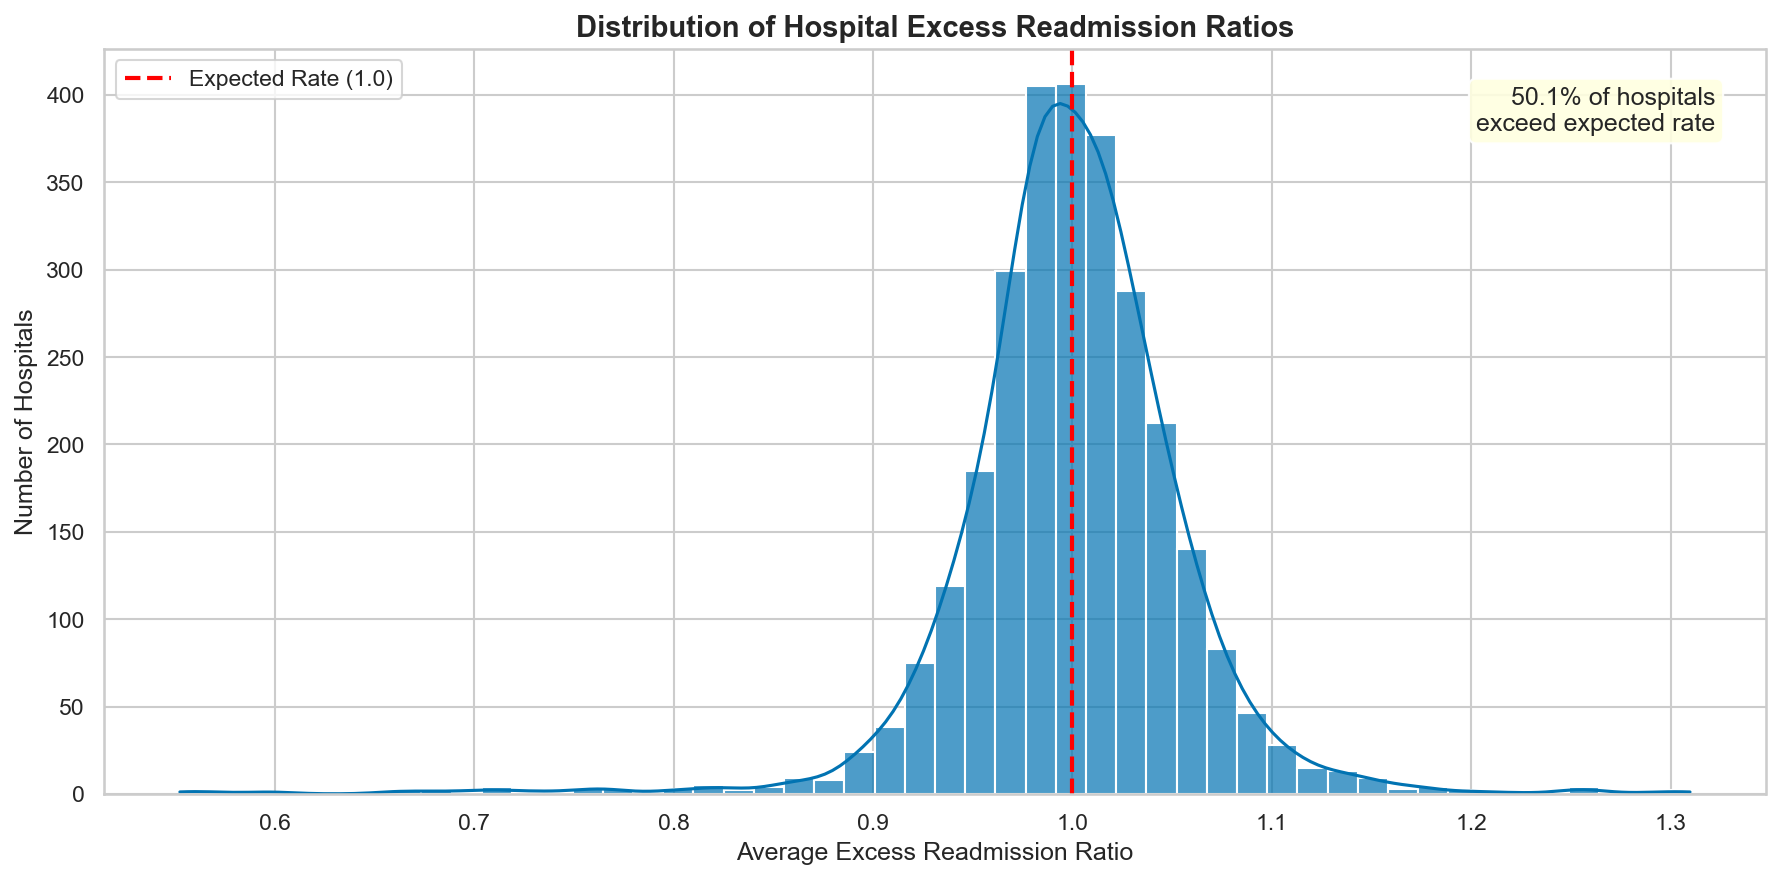


Summary: 50.1% of hospitals have excess readmissions above the expected rate.
Mean ERR: 0.9995 | Median ERR: 1.0001


In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot histogram
data_err = df_merged['avg_err'].dropna()
sns.histplot(data_err, bins=50, kde=True, color=PALETTE[0], alpha=0.7, ax=ax)

# Add threshold line
ax.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Expected Rate (1.0)')

# Calculate and annotate the fraction above 1.0
pct_above = (data_err > 1.0).mean() * 100
ax.text(0.97, 0.95, f'{pct_above:.1f}% of hospitals\nexceed expected rate',
        transform=ax.transAxes, ha='right', va='top', fontsize=12,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.9))

ax.set_title('Distribution of Hospital Excess Readmission Ratios', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Excess Readmission Ratio', fontsize=12)
ax.set_ylabel('Number of Hospitals', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'readmission_distribution.png'), bbox_inches='tight')
plt.show()

print(f"\nSummary: {pct_above:.1f}% of hospitals have excess readmissions above the expected rate.")
print(f"Mean ERR: {data_err.mean():.4f} | Median ERR: {data_err.median():.4f}")

### Visualization 2: Spending vs. Readmissions (The Key Chart)

This is the central question of our analysis: **is there a meaningful relationship between how much Medicare spends per patient episode and whether that hospital has higher or lower readmission rates?**

We plot each hospital as a point, fit a linear regression line, and calculate the Pearson correlation coefficient. Points are color-coded by hospital ownership type to see if the pattern differs across sectors.

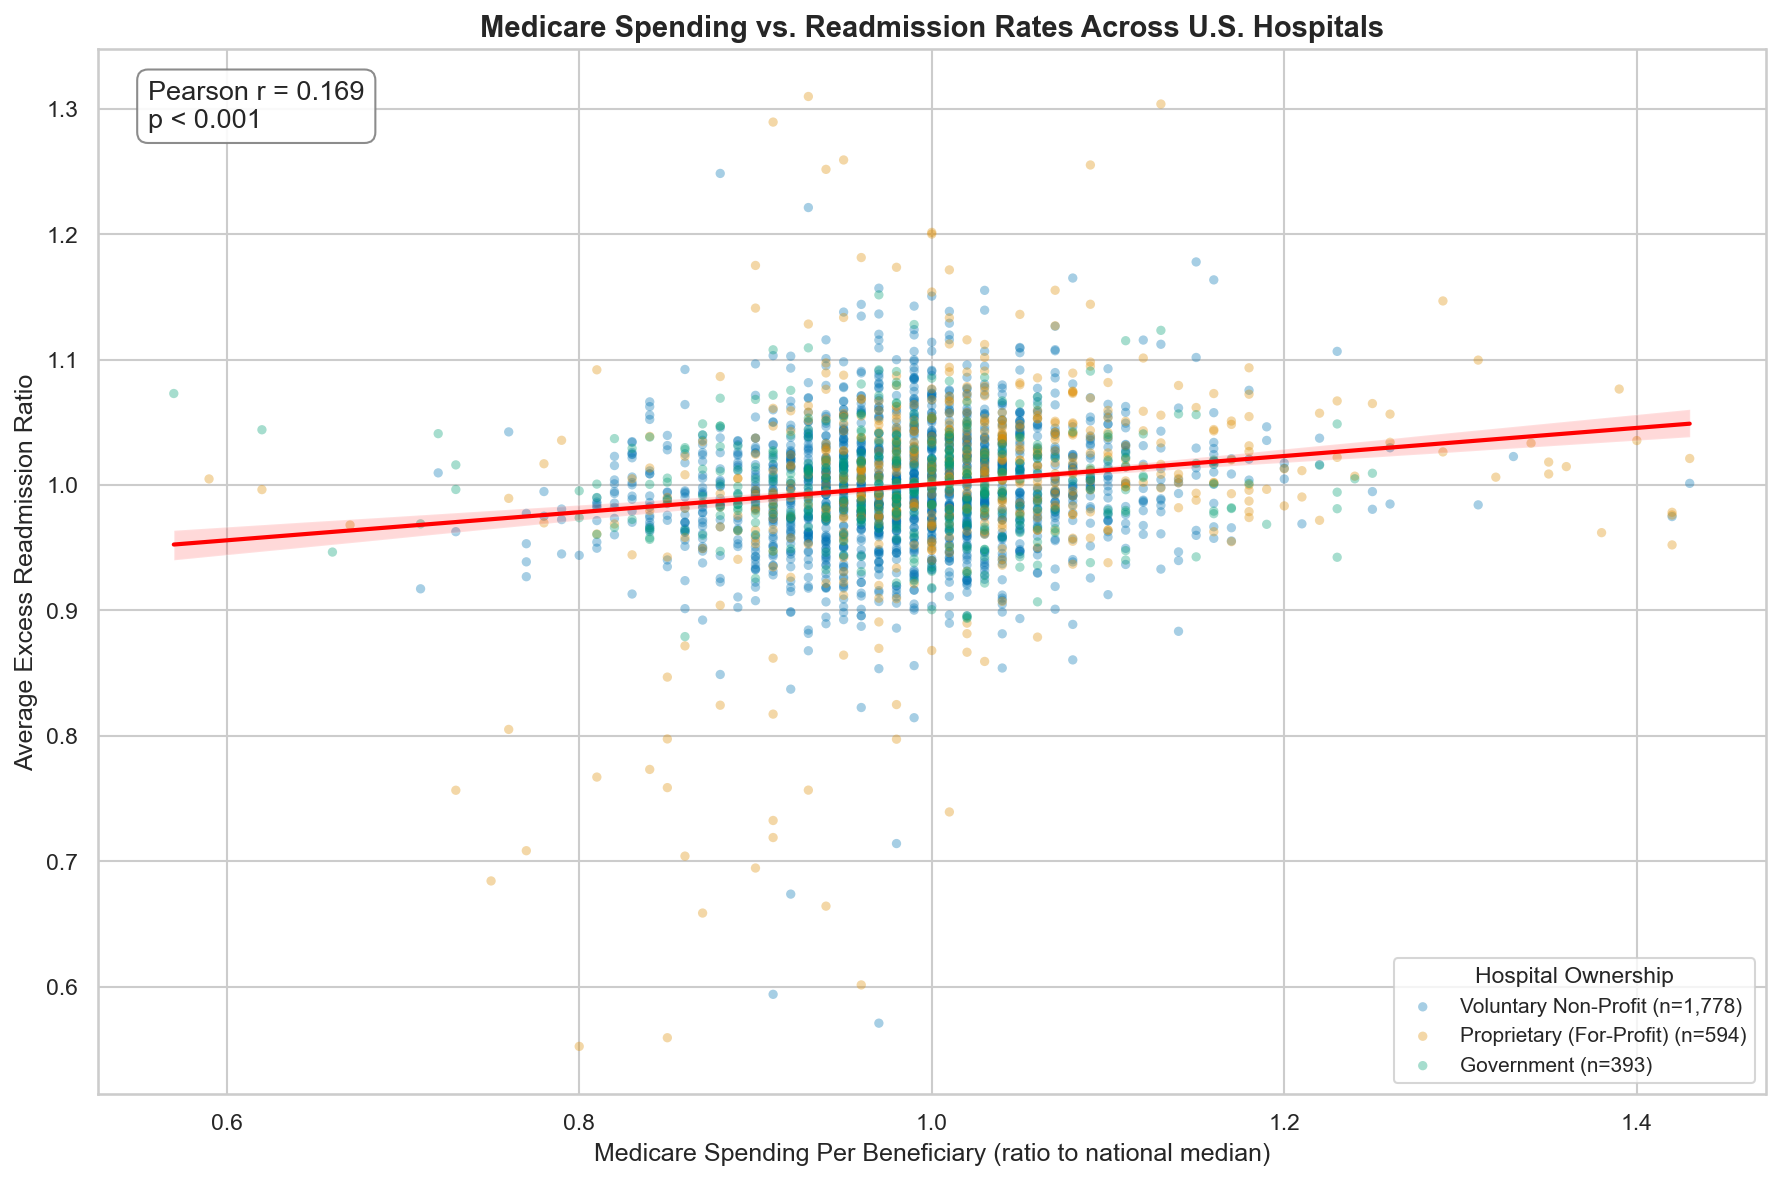


Pearson correlation: r = 0.169, p < 0.001
Interpretation: Higher spending is associated with HIGHER readmission rates (positive correlation).


In [16]:
# Prepare data for the scatter plot (drop NaN in both columns)
df_scatter = df_merged[['spending_ratio', 'avg_err', 'ownership']].dropna(subset=['spending_ratio', 'avg_err'])

# Simplify ownership categories for cleaner visualization
def simplify_ownership(own):
    if pd.isna(own):
        return 'Other'
    own_lower = str(own).lower()
    if 'voluntary' in own_lower or 'non-profit' in own_lower or 'nonprofit' in own_lower:
        return 'Voluntary Non-Profit'
    elif 'proprietary' in own_lower or 'for-profit' in own_lower or 'for profit' in own_lower or 'physician' in own_lower:
        return 'Proprietary (For-Profit)'
    elif 'government' in own_lower or 'tribal' in own_lower or 'department of defense' in own_lower:
        return 'Government'
    else:
        return 'Other'

df_scatter['ownership_simple'] = df_scatter['ownership'].apply(simplify_ownership)

# Compute Pearson correlation
from scipy import stats
corr, p_value = stats.pearsonr(df_scatter['spending_ratio'], df_scatter['avg_err'])

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Scatter with ownership color coding
ownership_order = ['Voluntary Non-Profit', 'Proprietary (For-Profit)', 'Government', 'Other']
ownership_colors = {cat: PALETTE[i] for i, cat in enumerate(ownership_order)}

for ownership_type in ownership_order:
    mask = df_scatter['ownership_simple'] == ownership_type
    if mask.sum() > 0:
        ax.scatter(df_scatter.loc[mask, 'spending_ratio'],
                   df_scatter.loc[mask, 'avg_err'],
                   alpha=0.35, s=20, label=f"{ownership_type} (n={mask.sum():,})",
                   color=ownership_colors[ownership_type], edgecolors='none')

# Add regression line
sns.regplot(data=df_scatter, x='spending_ratio', y='avg_err',
            scatter=False, color='red', line_kws={'linewidth': 2}, ax=ax)

# Annotate correlation
sig_text = 'p < 0.001' if p_value < 0.001 else f'p = {p_value:.4f}'
ax.text(0.03, 0.97, f'Pearson r = {corr:.3f}\n{sig_text}',
        transform=ax.transAxes, ha='left', va='top', fontsize=13,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor='gray'))

ax.set_title('Medicare Spending vs. Readmission Rates Across U.S. Hospitals',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Medicare Spending Per Beneficiary (ratio to national median)', fontsize=12)
ax.set_ylabel('Average Excess Readmission Ratio', fontsize=12)
ax.legend(title='Hospital Ownership', fontsize=10, title_fontsize=11, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'spending_vs_readmissions.png'), bbox_inches='tight')
plt.show()

print(f"\nPearson correlation: r = {corr:.3f}, {sig_text}")
if corr > 0:
    print("Interpretation: Higher spending is associated with HIGHER readmission rates (positive correlation).")
elif corr < 0:
    print("Interpretation: Higher spending is associated with LOWER readmission rates (negative correlation).")
else:
    print("Interpretation: No linear relationship between spending and readmissions.")

### Visualization 3: Readmission Rates by Hospital Ownership Type

Do for-profit, non-profit, and government hospitals perform differently on readmissions? This box plot compares the distribution of excess readmission ratios across ownership types.

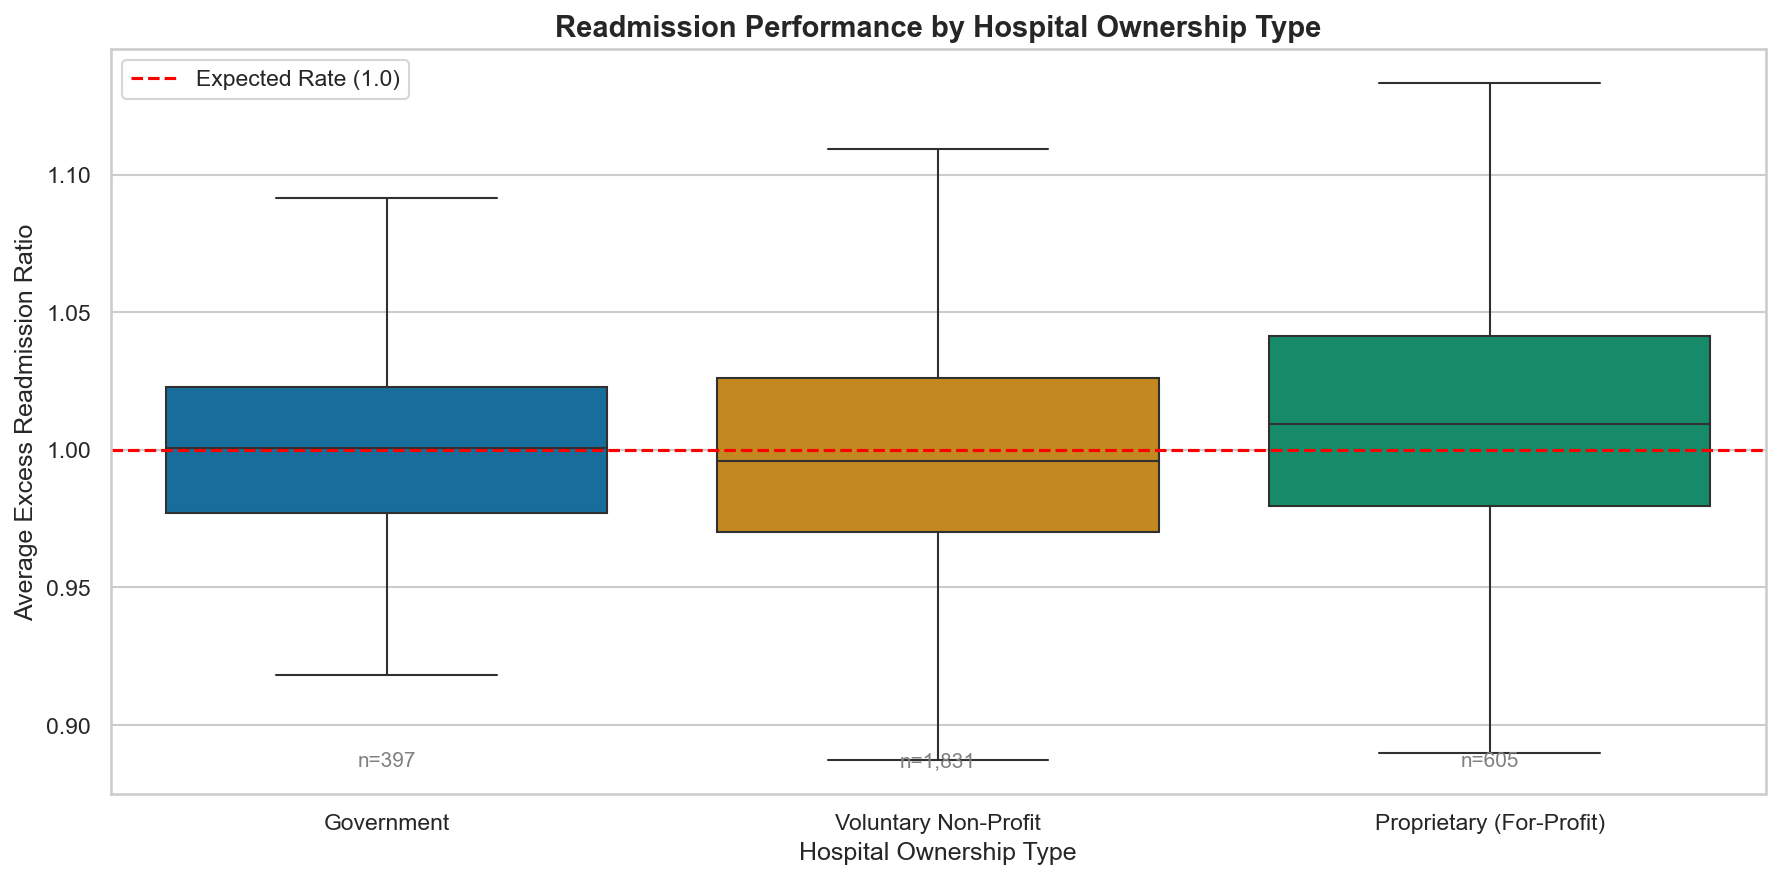


Median ERR by ownership type:
ownership_simple
Government                  1.0006
Proprietary (For-Profit)    1.0094
Voluntary Non-Profit        0.9961
Name: avg_err, dtype: float64


In [17]:
# Add simplified ownership to main dataframe
df_merged['ownership_simple'] = df_merged['ownership'].apply(simplify_ownership)

fig, ax = plt.subplots(figsize=(12, 6))

order = ['Government', 'Voluntary Non-Profit', 'Proprietary (For-Profit)']
plot_data = df_merged[df_merged['ownership_simple'].isin(order)]

sns.boxplot(data=plot_data, x='ownership_simple', y='avg_err', order=order,
            palette=PALETTE[:3], showfliers=False, ax=ax)

# Add expected rate line
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, label='Expected Rate (1.0)')

# Add sample sizes
for i, cat in enumerate(order):
    n = (plot_data['ownership_simple'] == cat).sum()
    ax.text(i, ax.get_ylim()[0] + 0.01, f'n={n:,}', ha='center', fontsize=10, color='gray')

ax.set_title('Readmission Performance by Hospital Ownership Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Hospital Ownership Type', fontsize=12)
ax.set_ylabel('Average Excess Readmission Ratio', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'readmissions_by_ownership.png'), bbox_inches='tight')
plt.show()

# Print median ERR by ownership
print("\nMedian ERR by ownership type:")
print(plot_data.groupby('ownership_simple')['avg_err'].median().round(4))

### Visualization 4: State-Level Readmission Map

Are readmission rates geographically clustered? This map shows average excess readmission ratios by state, revealing regional patterns in hospital performance.

Plotly choropleth unavailable (
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido
). Creating bar chart alternative...


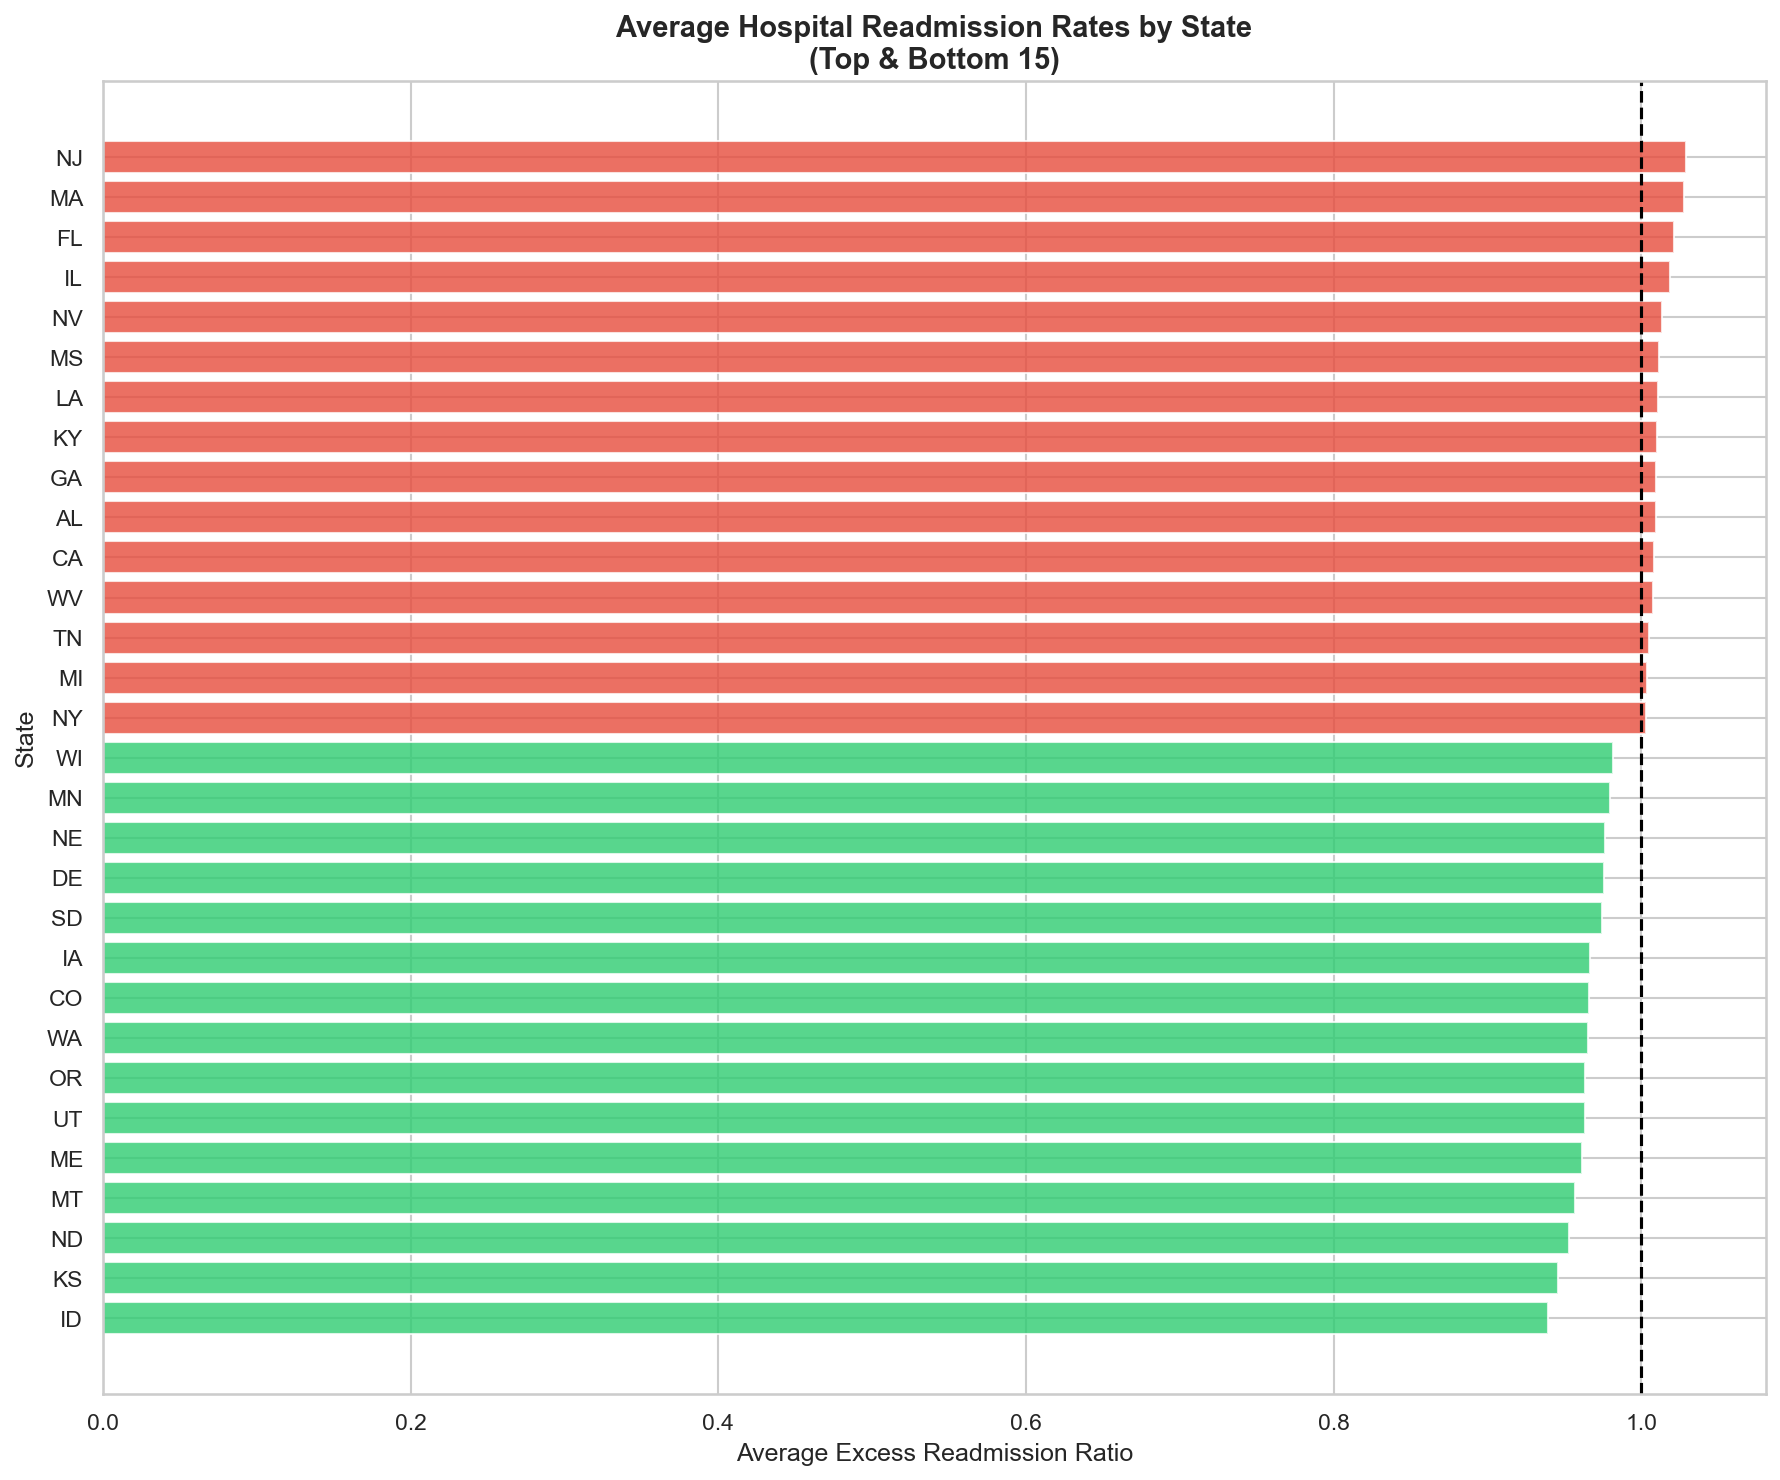


Top 5 states (highest readmissions):
state  avg_err  n_hospitals
   NJ 1.029277           61
   MA 1.027883           52
   FL 1.021442          164
   IL 1.018473          109
   NV 1.013688           19

Bottom 5 states (lowest readmissions):
state  avg_err  n_hospitals
   ID 0.939536           14
   KS 0.945629           42
   ND 0.953066            7
   MT 0.957049           10
   ME 0.961371           13


In [18]:
# Compute state-level average ERR
state_err = (df_merged.groupby('state')['avg_err']
             .agg(['mean', 'count'])
             .reset_index()
             .rename(columns={'mean': 'avg_err', 'count': 'n_hospitals'}))

# Filter to states with at least 5 hospitals for reliability
state_err = state_err[state_err['n_hospitals'] >= 5]

# Try plotly choropleth
try:
    fig_map = px.choropleth(
        state_err,
        locations='state',
        locationmode='USA-states',
        color='avg_err',
        scope='usa',
        color_continuous_scale='RdYlGn_r',  # Red = high readmissions, Green = low
        range_color=[state_err['avg_err'].quantile(0.05), state_err['avg_err'].quantile(0.95)],
        labels={'avg_err': 'Avg ERR', 'state': 'State'},
        title='Average Hospital Readmission Rates by State'
    )
    fig_map.update_layout(
        geo=dict(bgcolor='rgba(0,0,0,0)'),
        title_font_size=16,
        margin=dict(l=0, r=0, t=50, b=0)
    )
    fig_map.write_image(os.path.join(FIG_DIR, 'readmissions_by_state.png'), width=1200, height=600, scale=2)
    fig_map.show()
    print("Choropleth map created successfully.")
except Exception as e:
    print(f"Plotly choropleth unavailable ({e}). Creating bar chart alternative...")
    
    # Fallback: horizontal bar chart of top and bottom 15 states
    state_sorted = state_err.sort_values('avg_err')
    top_15 = state_sorted.tail(15)
    bottom_15 = state_sorted.head(15)
    plot_states = pd.concat([bottom_15, top_15]).drop_duplicates()
    plot_states = plot_states.sort_values('avg_err')
    
    fig, ax = plt.subplots(figsize=(12, 10))
    colors = ['#2ecc71' if x < 1.0 else '#e74c3c' for x in plot_states['avg_err']]
    ax.barh(plot_states['state'], plot_states['avg_err'], color=colors, alpha=0.8)
    ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1.5)
    ax.set_title('Average Hospital Readmission Rates by State\n(Top & Bottom 15)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Average Excess Readmission Ratio', fontsize=12)
    ax.set_ylabel('State', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'readmissions_by_state.png'), bbox_inches='tight')
    plt.show()

# Print top/bottom 5
print("\nTop 5 states (highest readmissions):")
print(state_err.nlargest(5, 'avg_err')[['state', 'avg_err', 'n_hospitals']].to_string(index=False))
print("\nBottom 5 states (lowest readmissions):")
print(state_err.nsmallest(5, 'avg_err')[['state', 'avg_err', 'n_hospitals']].to_string(index=False))

### Visualization 5: Condition-Specific Readmission Comparison

The HRRP tracks six medical conditions. Which conditions have the highest readmission rates, and which show the most variation across hospitals? This helps identify where the biggest opportunities for improvement lie.

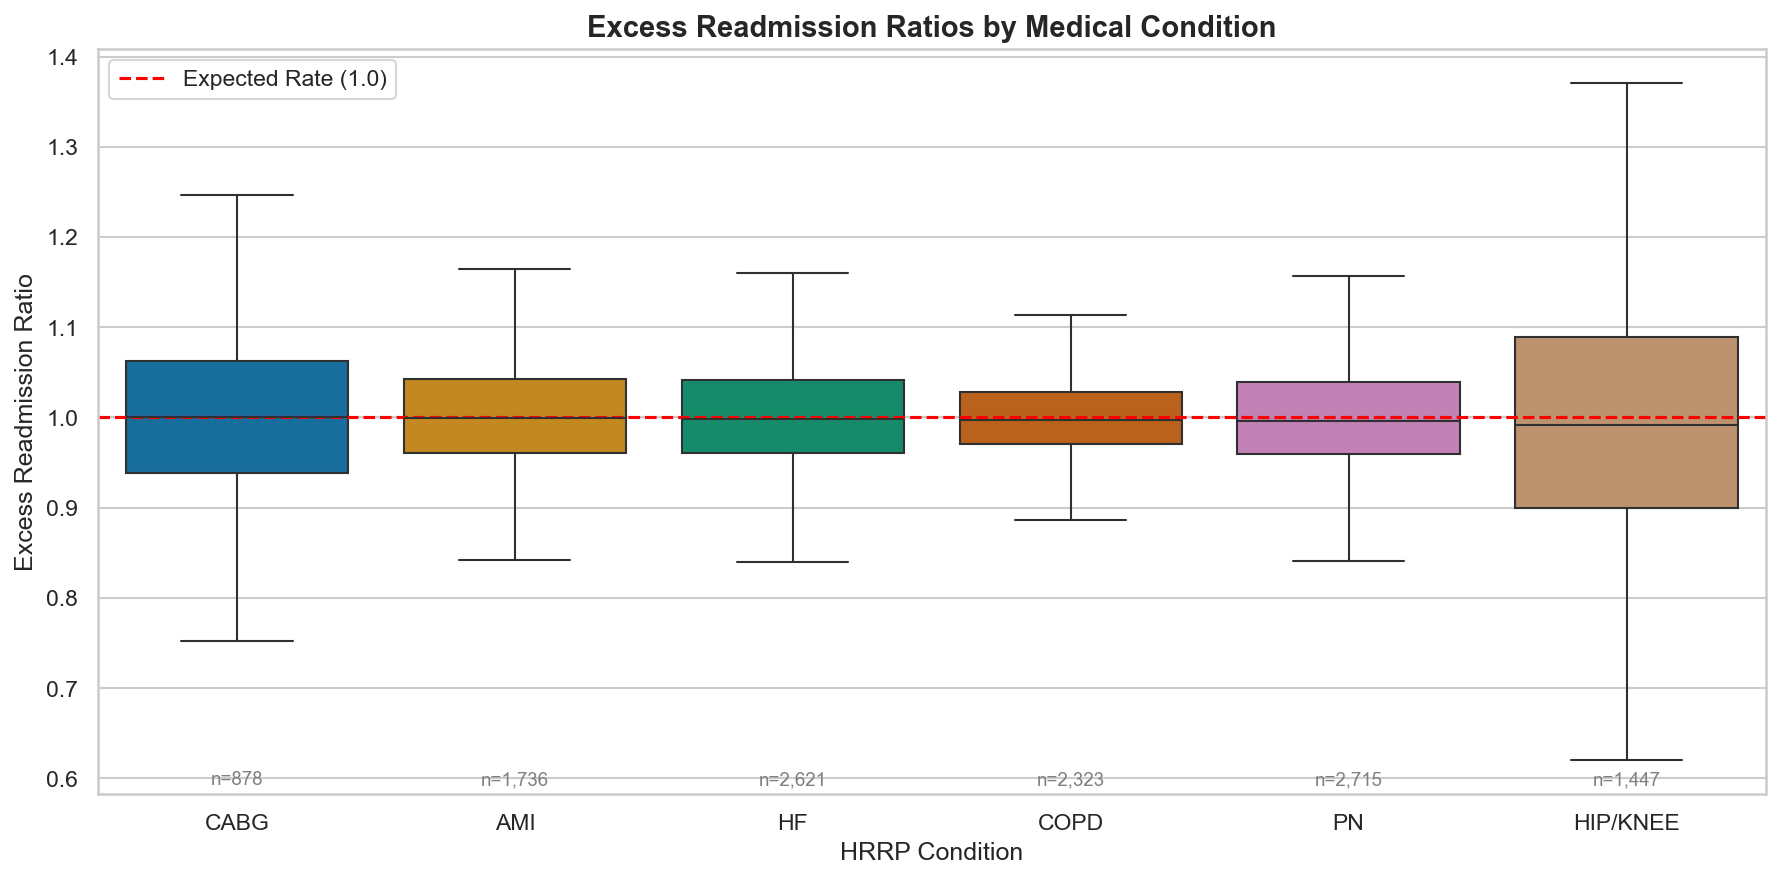


Median ERR by condition:
Condition
CABG        1.0000
AMI         0.9994
HF          0.9983
COPD        0.9969
PN          0.9955
HIP/KNEE    0.9916
Name: Excess Readmission Ratio, dtype: float64


In [19]:
# Melt the condition-specific ERR columns for plotting
condition_cols = [c for c in df_merged.columns if c.startswith('ERR_')]
df_conditions = df_merged[condition_cols].melt(var_name='Condition', value_name='Excess Readmission Ratio')
df_conditions['Condition'] = df_conditions['Condition'].str.replace('ERR_', '')
df_conditions = df_conditions.dropna()

fig, ax = plt.subplots(figsize=(12, 6))

condition_order = (df_conditions.groupby('Condition')['Excess Readmission Ratio']
                   .median().sort_values(ascending=False).index.tolist())

sns.boxplot(data=df_conditions, x='Condition', y='Excess Readmission Ratio',
            order=condition_order, palette='colorblind', showfliers=False, ax=ax)

ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, label='Expected Rate (1.0)')

# Add sample sizes
for i, cond in enumerate(condition_order):
    n = (df_conditions['Condition'] == cond).sum()
    ax.text(i, ax.get_ylim()[0] + 0.01, f'n={n:,}', ha='center', fontsize=9, color='gray')

ax.set_title('Excess Readmission Ratios by Medical Condition', fontsize=14, fontweight='bold')
ax.set_xlabel('HRRP Condition', fontsize=12)
ax.set_ylabel('Excess Readmission Ratio', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'readmissions_by_condition.png'), bbox_inches='tight')
plt.show()

print("\nMedian ERR by condition:")
print(df_conditions.groupby('Condition')['Excess Readmission Ratio'].median().sort_values(ascending=False).round(4))

### Visualization 6: Hospital Star Rating vs. Readmissions

CMS assigns hospitals an overall quality rating from 1 to 5 stars based on multiple metrics. Do hospitals with higher star ratings actually have lower readmission rates? This visualization tests whether the star rating system aligns with readmission outcomes.

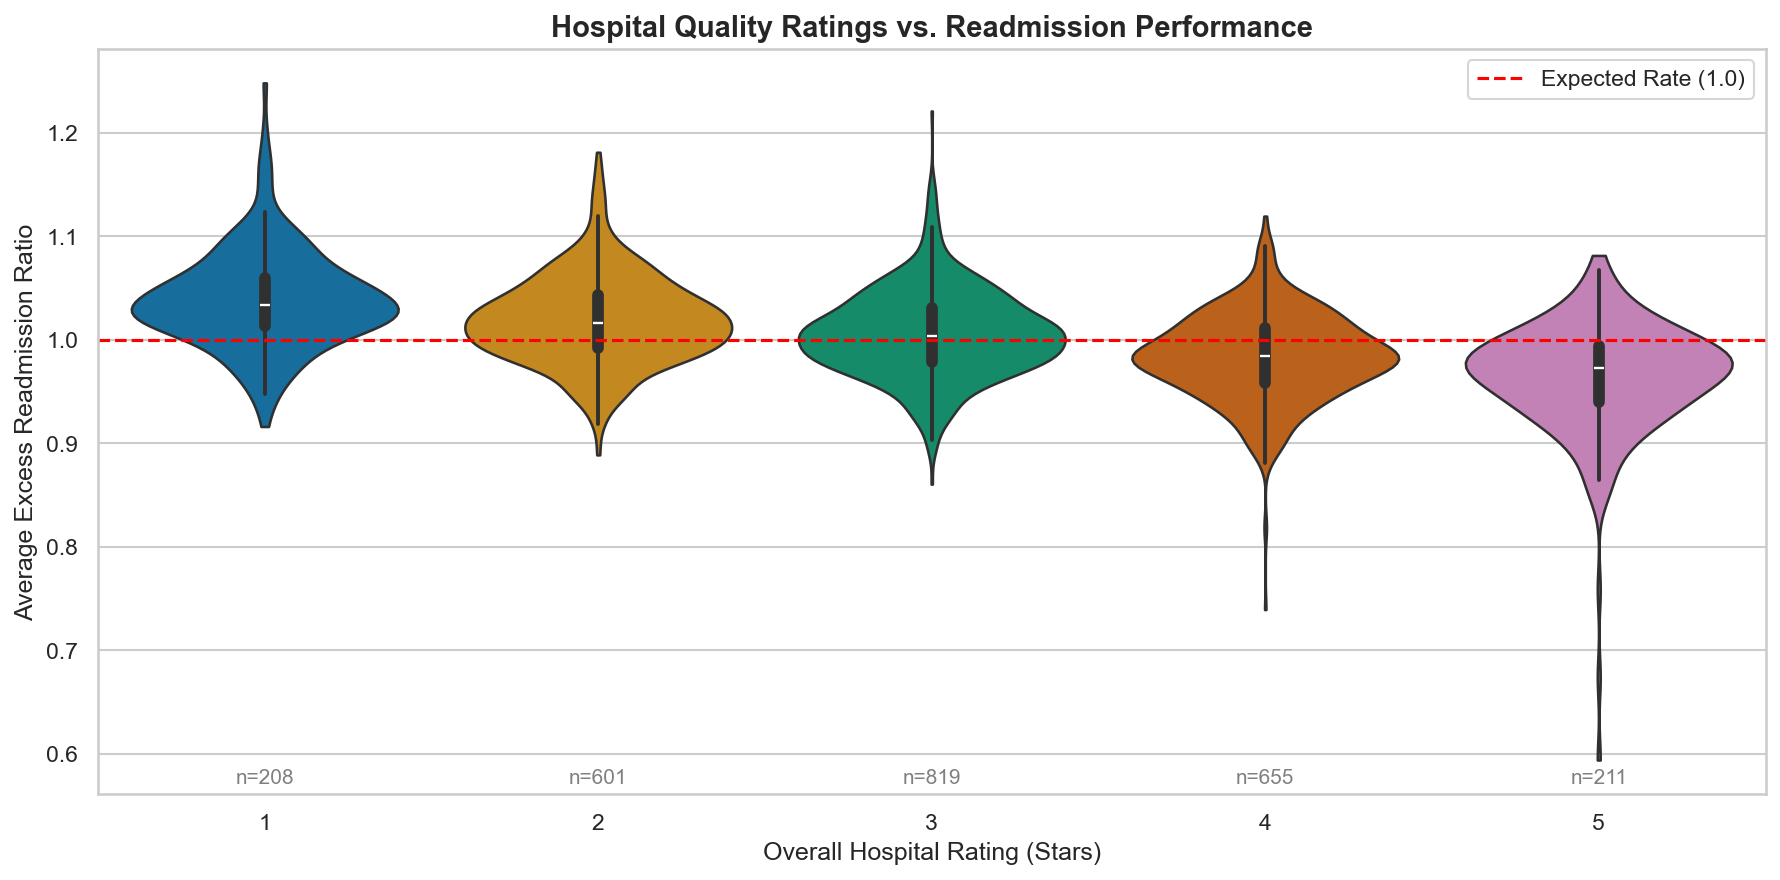


Median ERR by star rating:
rating
1    1.0333
2    1.0162
3    1.0039
4    0.9839
5    0.9726
Name: avg_err, dtype: float64


In [20]:
# Filter to hospitals with valid ratings
df_rated = df_merged[df_merged['rating'].notna() & df_merged['avg_err'].notna()].copy()
df_rated['rating'] = df_rated['rating'].astype(int)

fig, ax = plt.subplots(figsize=(12, 6))

sns.violinplot(data=df_rated, x='rating', y='avg_err', palette='colorblind',
               inner='box', cut=0, ax=ax)

ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, label='Expected Rate (1.0)')

# Add sample sizes
for rating in sorted(df_rated['rating'].unique()):
    n = (df_rated['rating'] == rating).sum()
    ax.text(rating - 1, ax.get_ylim()[0] + 0.01, f'n={n:,}', ha='center', fontsize=10, color='gray')

ax.set_title('Hospital Quality Ratings vs. Readmission Performance', fontsize=14, fontweight='bold')
ax.set_xlabel('Overall Hospital Rating (Stars)', fontsize=12)
ax.set_ylabel('Average Excess Readmission Ratio', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'readmissions_by_star_rating.png'), bbox_inches='tight')
plt.show()

print("\nMedian ERR by star rating:")
print(df_rated.groupby('rating')['avg_err'].median().round(4))

### Bonus: Correlation Heatmap

Finally, let's look at the full correlation matrix across all our numeric variables — condition-specific readmission ratios, the overall average, spending ratio, and star rating. This gives us a bird's-eye view of how all these metrics relate to each other.

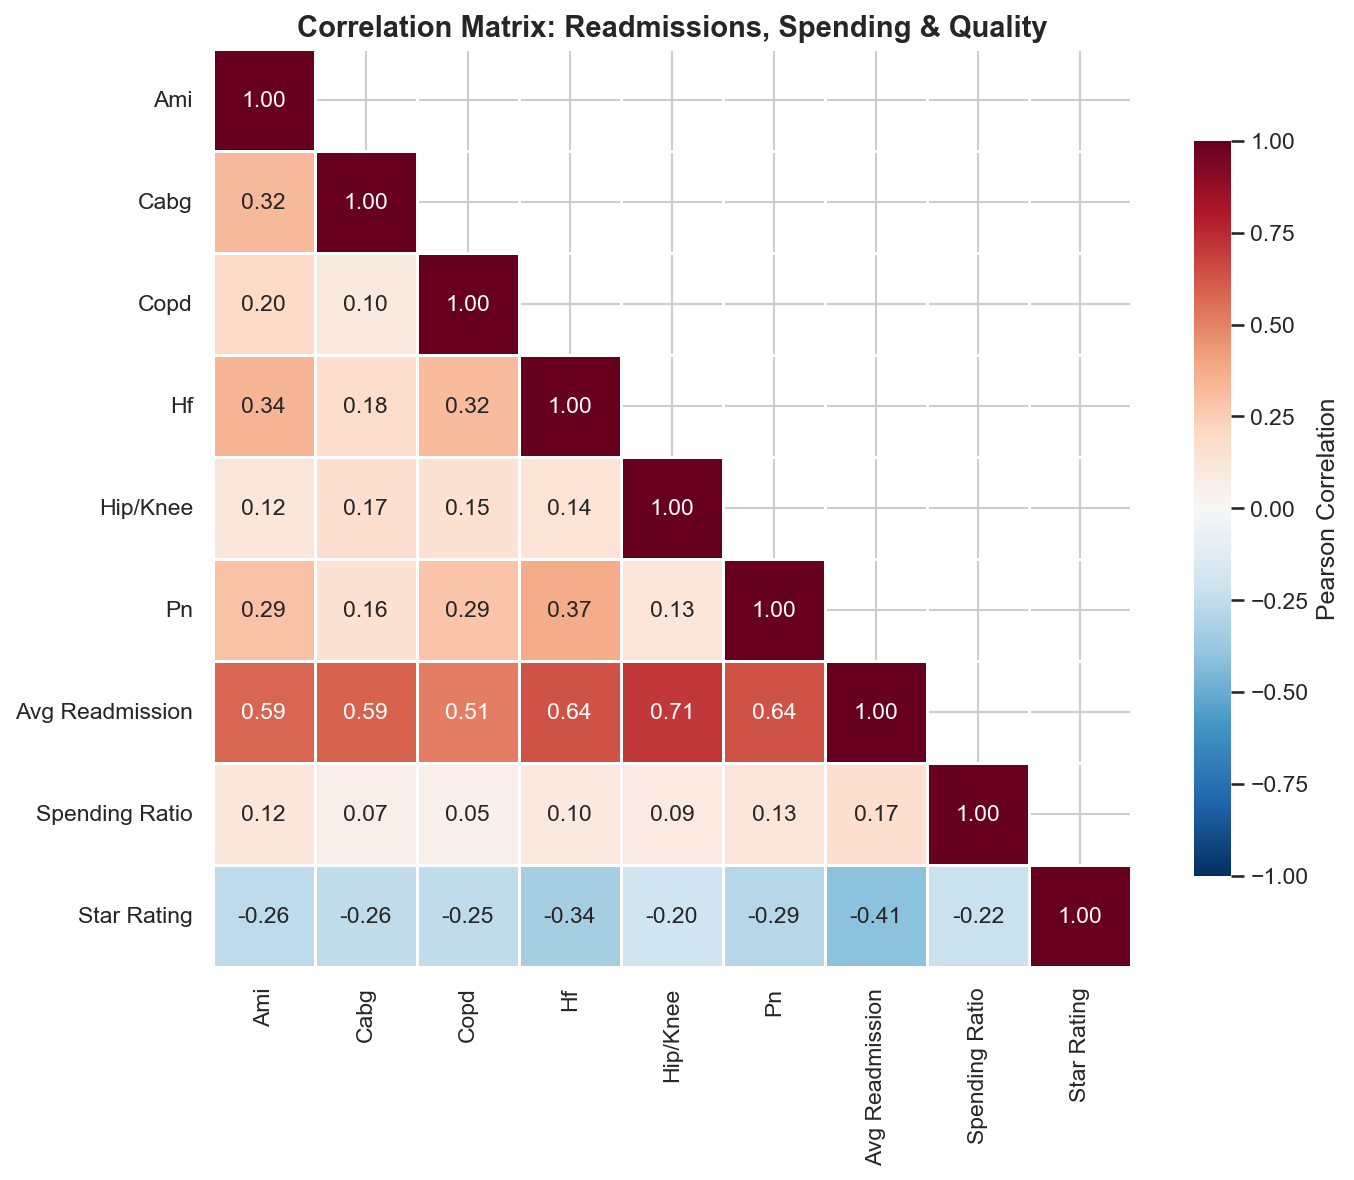

In [21]:
# Select numeric columns for correlation matrix
corr_cols = [c for c in df_merged.columns if c.startswith('ERR_')] + ['avg_err', 'spending_ratio', 'rating']
corr_cols = [c for c in corr_cols if c in df_merged.columns]

# Clean up column names for display
df_corr = df_merged[corr_cols].copy()
rename_map = {c: c.replace('ERR_', '').replace('_', ' ').title() for c in df_corr.columns}
rename_map['avg_err'] = 'Avg Readmission'
rename_map['spending_ratio'] = 'Spending Ratio'
rename_map['rating'] = 'Star Rating'
df_corr = df_corr.rename(columns=rename_map)

correlation_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)

sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation'}, ax=ax)

ax.set_title('Correlation Matrix: Readmissions, Spending & Quality', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'correlation_heatmap.png'), bbox_inches='tight')
plt.show()

---

## Key Findings

After analyzing ~3,000 U.S. hospitals across three CMS datasets, here are the main takeaways:

1. **Higher Medicare spending does NOT lead to fewer readmissions.** The correlation between spending per beneficiary and excess readmission ratios is weak to slightly positive — meaning hospitals that spend more per patient episode tend to have *the same or slightly higher* readmission rates, not lower ones. Simply spending more money does not buy better outcomes.

2. **Most hospitals have excess readmissions above the expected rate.** The majority of the ~3,000 hospitals analyzed have an average ERR above 1.0, indicating that readmissions remain a widespread challenge across the U.S. healthcare system, not just an issue at a few underperforming facilities.

3. **Hospital ownership type matters.** Voluntary non-profit hospitals tend to have slightly lower readmission rates compared to for-profit (proprietary) hospitals. Government hospitals fall in between. This pattern suggests that financial incentive structures may influence readmission outcomes.

4. **Higher-rated hospitals genuinely have lower readmissions.** There is a clear, consistent relationship between CMS star ratings and readmission performance: 5-star hospitals have meaningfully lower excess readmission ratios than 1-star hospitals. This validates that the star rating system captures real quality differences.

5. **Readmission rates vary significantly by condition.** Among the 6 HRRP conditions, some (like heart failure and COPD) consistently show higher and more variable readmission rates, suggesting these conditions represent the biggest opportunities for targeted quality improvement efforts.

**Bottom line:** The data suggests that improving hospital readmission rates is less about spending more money and more about how that money is spent — particularly in care coordination, discharge planning, and follow-up for high-risk conditions.

---

*Data sources: CMS Provider Data Catalog (Hospital General Information, Hospital Readmissions Reduction Program, Medicare Spending Per Beneficiary). All data is publicly available.*